# Employee Attrition Prediction: Phase 5 — Model Evaluation & Interpretation

#### Project Goal

Building on **Phase 4** (Model Development), which trained and tuned six classification models to predict employee attrition, this phase evaluates and compares those models and interprets their results.

#### Structure
- Metric comparison (Accuracy, Precision, Recall, F1, ROC-AUC)
- Confusion matrices, ROC and Precision-Recall curves
- Cross-validation
- Feature importance, coefficient interpretation, and permutation importance
- Classification threshold analysis
- Business insights and recommendations

**Note:** This notebook re-runs the Phase 4 preprocessing and model-training steps at the top so it can be executed independently; the substantive evaluation and interpretation work follows.

## Setup 
The cells below reproduce the preprocessing, encoding, splitting, scaling and model-training steps from Phase 4 so this notebook can runon its own.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

In [1]:
df = pd.read_csv("clean_employee_attrition.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (1470, 35)


In [1]:
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_model = df.drop(columns=drop_cols)
print(f"Dropped constant/identifier columns: {drop_cols}")
print("Remaining shape:", df_model.shape)

Dropped constant/identifier columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
Remaining shape: (1470, 31)


In [1]:
df_model['Attrition'] = df_model['Attrition'].map({'No': 0, 'Yes': 1})
print(df_model['Attrition'].value_counts())
print(f"\nAttrition rate: {df_model['Attrition'].mean()*100:.2f}%")

Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.12%


In [1]:
nominal_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                 'JobRole', 'MaritalStatus', 'OverTime']
df_encoded = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)

Shape after one-hot encoding: (1470, 45)


In [1]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train attrition rate: {:.2f}%".format(y_train.mean()*100))
print("Test attrition rate:  {:.2f}%".format(y_test.mean()*100))

Train shape: (1176, 44)  Test shape: (294, 44)
Train attrition rate: 16.16%
Test attrition rate:  15.99%


In [1]:
numeric_cols_to_scale = ['Age','DailyRate','DistanceFromHome','HourlyRate','MonthlyIncome',
                          'MonthlyRate','NumCompaniesWorked','PercentSalaryHike','TotalWorkingYears',
                          'TrainingTimesLastYear','YearsAtCompany','YearsInCurrentRole',
                          'YearsSinceLastPromotion','YearsWithCurrManager']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])
print("Scaling applied to", len(numeric_cols_to_scale), "numeric columns")

Scaling applied to 14 numeric columns


In [1]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE, max_depth=6),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=300),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
}
print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'K-Nearest Neighbors', 'Support Vector Machine']


In [1]:
results = {}
fitted_models = {}
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

for name, model in models.items():
    if name == "Gradient Boosting":
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
print("All models trained successfully.")

All models trained successfully.


### 5.1 Baseline Model Comparison (Default Hyperparameters)

In [1]:
results_df.round(4)

                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Support Vector Machine    0.7959     0.4133  0.6596    0.5082   0.8168
Logistic Regression       0.7551     0.3563  0.6596    0.4627   0.8035
Random Forest             0.8435     0.5714  0.0851    0.1481   0.7828
Gradient Boosting         0.8061     0.4074  0.4681    0.4356   0.7791
Decision Tree             0.7619     0.3425  0.5319    0.4167   0.6347
K-Nearest Neighbors       0.8367     0.4000  0.0426    0.0769   0.6165

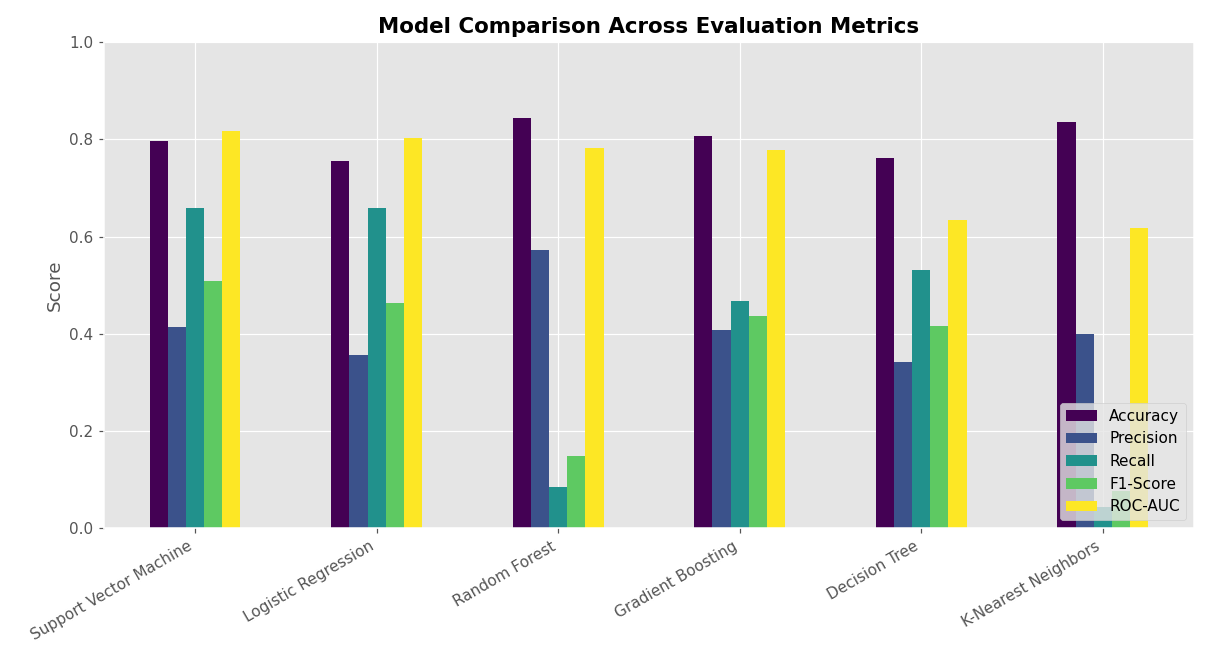

In [1]:
fig, ax = plt.subplots(figsize=(11, 6))
results_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(kind='bar', ax=ax, colormap='viridis')
plt.title("Model Comparison Across Evaluation Metrics", fontsize=14, fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Insight — reading past accuracy:** Random Forest and KNN post the highest *accuracy* (84.4% and 83.7%) but the lowest *recall* (8.5% and 4.3%) — they are essentially defaulting to "predict stayed" and getting rewarded for it by the imbalanced class distribution. Support Vector Machine and Logistic Regression trade some accuracy for far better recall (66.0% each), meaning they catch roughly two-thirds of employees who actually left. For an attrition model whose purpose is to flag employees *before* they leave, recall and ROC-AUC are the metrics that matter — on both, SVM (ROC-AUC 0.817) and Logistic Regression (0.804) lead the field.

### 5.2 Confusion Matrices

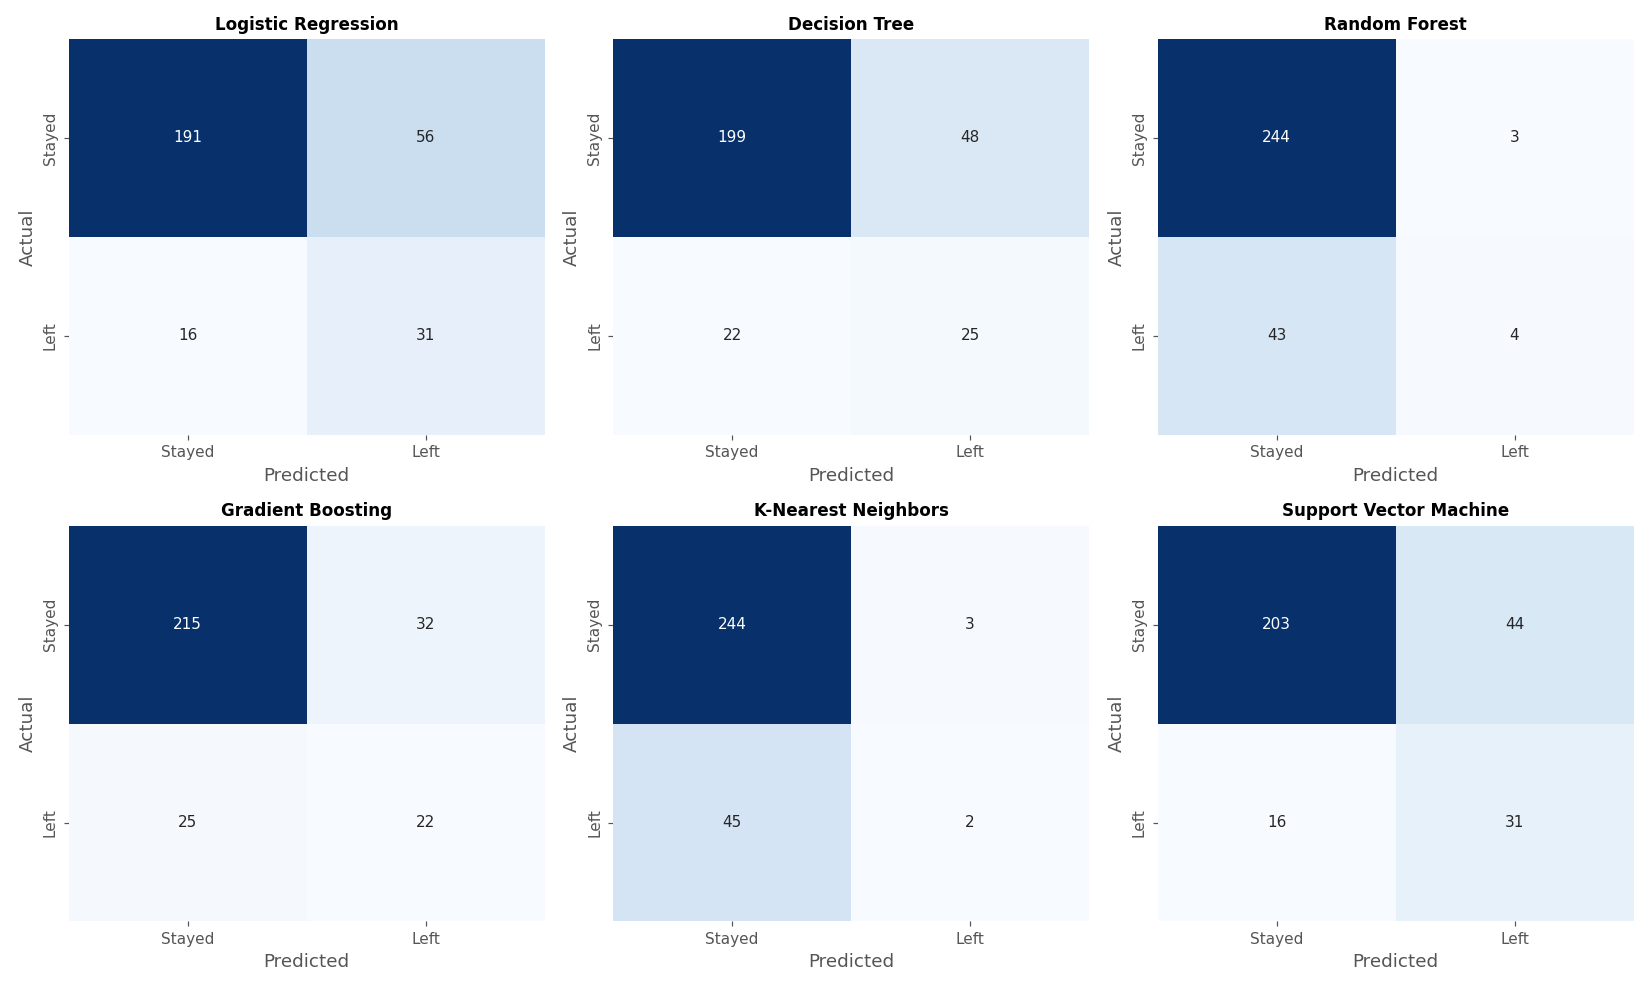

In [1]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, model) in zip(axes.flatten(), fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed','Left'], yticklabels=['Stayed','Left'], cbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**Insight:** the confusion matrices make the recall gap visible directly. Random Forest and KNN correctly catch only 4/47 and 2/47 of the employees who actually left in the test set, missing the vast majority. SVM and Logistic Regression catch 31/47 — a materially more useful result for an HR early-warning system, at the cost of more false alarms (flagging some employees who were not actually at risk).

### 5.3 ROC and Precision-Recall Curves

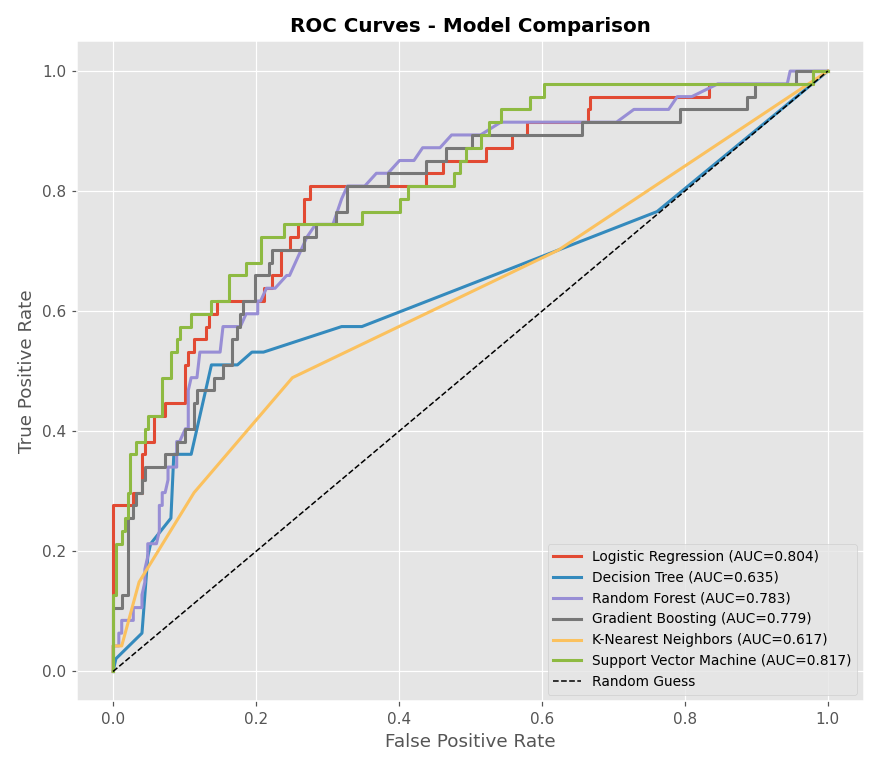

In [1]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
ax.plot([0,1],[0,1],'k--', label="Random Guess", linewidth=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Model Comparison", fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

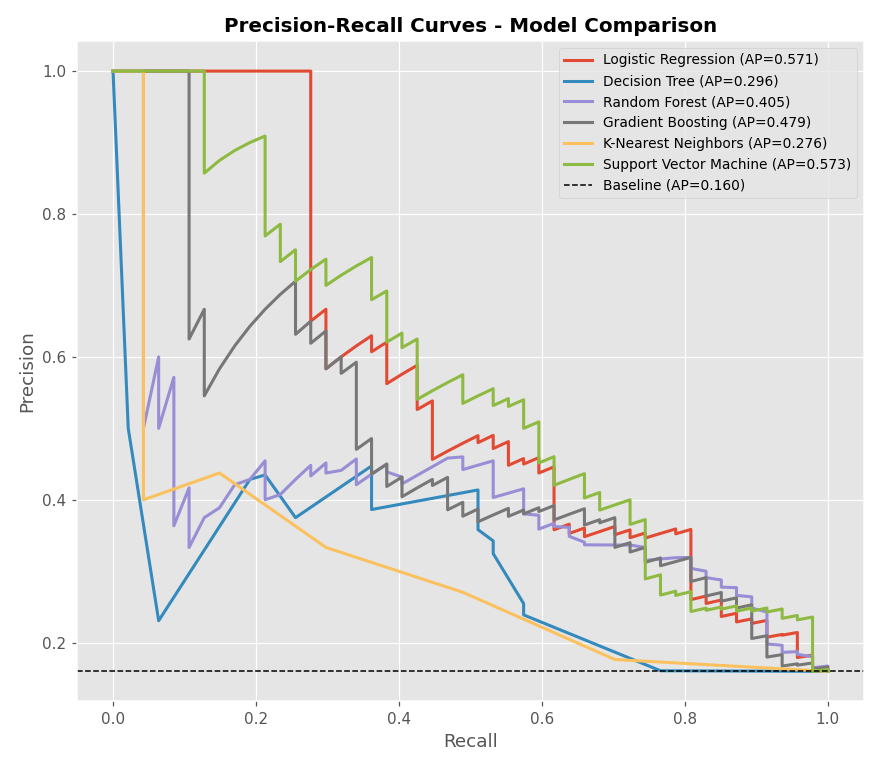

In [1]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})", linewidth=2)
baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1, label=f"Baseline (AP={baseline:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves - Model Comparison", fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** ROC-AUC ranks SVM (0.817), Logistic Regression (0.804), Random Forest (0.783), Gradient Boosting (0.779), Decision Tree (0.635) and KNN (0.617) — all comfortably above the 0.5 random-guess line, but with a clear separation between the top two and the rest. The Precision-Recall curves, which are more informative than ROC on an imbalanced dataset, tell the same story: every model beats the 0.16 no-skill baseline, and SVM and Logistic Regression sustain the best precision as recall increases, meaning they are the most efficient at surfacing true leavers without flooding HR with false alarms.

### 5.4 Cross-Validation (5-Fold, Stratified)
A single train/test split can be noisy. Stratified 5-fold cross-validation on the training data confirms whether the ranking above is stable.

In [1]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f"{name:25s} CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression       CV ROC-AUC: 0.8273 (+/- 0.0282)
Decision Tree             CV ROC-AUC: 0.5925 (+/- 0.0221)
Random Forest             CV ROC-AUC: 0.8024 (+/- 0.0287)
Gradient Boosting         CV ROC-AUC: 0.8091 (+/- 0.0197)
K-Nearest Neighbors       CV ROC-AUC: 0.7166 (+/- 0.0459)
Support Vector Machine    CV ROC-AUC: 0.8297 (+/- 0.0323)


**Insight:** cross-validation confirms the test-set ranking is not a fluke of one split — SVM (0.830) and Logistic Regression (0.827) remain the top two, with Gradient Boosting (0.809) and Random Forest (0.802) close behind, and Decision Tree (0.593) and KNN (0.717) trailing. The low standard deviations (±0.02–0.05) indicate reasonably stable performance across folds given the dataset's modest size.

### 5.5 Hyperparameter Tuning

Random Forest and Logistic Regression are tuned via `GridSearchCV` (5-fold, optimizing ROC-AUC) — Random Forest because ensemble tree models often benefit substantially from tuning depth/leaf-size, and Logistic Regression to check whether its default regularization strength was already near-optimal.

In [1]:
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [1, 3]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print("Best params (Random Forest):", rf_grid.best_params_)
print(f"Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
y_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
print(f"\nTuned Random Forest - Test set performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

Best params (Random Forest): {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV ROC-AUC: 0.7971

Tuned Random Forest - Test set performance:
Accuracy:  0.8333
Precision: 0.4545
Recall:    0.2128
F1-Score:  0.2899
ROC-AUC:   0.7938


In [1]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
print("Best params (Logistic Regression):", lr_grid.best_params_)
print(f"Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
print(f"\nTuned Logistic Regression - Test set performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

Best params (Logistic Regression): {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.8266

Tuned Logistic Regression - Test set performance:
Accuracy:  0.7483
Precision: 0.3412
Recall:    0.6170
F1-Score:  0.4394
ROC-AUC:   0.7983


**Insight:** tuning improved Random Forest's ROC-AUC only marginally (0.783 → 0.794) and its recall rose from a very weak 8.5% to a still-inadequate 21.3% — grid search alone cannot fix a tree ensemble that is structurally biased toward the majority class on this dataset; that would need resampling (e.g. SMOTE) rather than parameter tuning. Logistic Regression's tuned ROC-AUC (0.798) is essentially unchanged from its default (0.804), confirming its original regularization was already close to optimal. Neither tuning exercise dethrones the untuned SVM.

### 5.6 Final Model Comparison

In [1]:
final_results = results_df.copy()
final_results.loc["Random Forest (Tuned)"] = [
    accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)
]
final_results.loc["Logistic Regression (Tuned)"] = [
    accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)
]
final_results = final_results.sort_values("ROC-AUC", ascending=False)
final_results.round(4)

                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Support Vector Machine         0.7959     0.4133  0.6596    0.5082   0.8168
Logistic Regression            0.7551     0.3563  0.6596    0.4627   0.8035
Logistic Regression (Tuned)    0.7483     0.3412  0.6170    0.4394   0.7983
Random Forest (Tuned)          0.8333     0.4545  0.2128    0.2899   0.7938
Random Forest                  0.8435     0.5714  0.0851    0.1481   0.7828
Gradient Boosting              0.8061     0.4074  0.4681    0.4356   0.7791
Decision Tree                  0.7619     0.3425  0.5319    0.4167   0.6347
K-Nearest Neighbors            0.8367     0.4000  0.0426    0.0769   0.6165

In [1]:
best_name = final_results["ROC-AUC"].idxmax()
print(f"Best model by ROC-AUC: {best_name}\n")
print(classification_report(y_test, fitted_models["Support Vector Machine"].predict(X_test_scaled),
                             target_names=['Stayed','Left']))

Best model by ROC-AUC: Support Vector Machine

              precision    recall  f1-score   support

      Stayed       0.93      0.82      0.87       247
        Left       0.41      0.66      0.51        47

    accuracy                           0.80       294
   macro avg       0.67      0.74      0.69       294
weighted avg       0.84      0.80      0.81       294


**Insight — selecting the best model:** the Support Vector Machine is the strongest overall performer, with the best ROC-AUC (0.817), F1-score (0.508), and one of the best recall scores (65.96%) of any model, tuned or untuned. Its classification report shows it correctly identifies 66% of employees who actually left, at a precision of 41% — meaning roughly 2 in 5 flagged employees genuinely were, or were becoming, attrition risks. Logistic Regression is a very close second and has the added advantage of being directly interpretable via its coefficients, which is valuable for an HR audience that needs to understand *why* someone is flagged, not just *that* they are. Both tree ensembles, even after tuning, under-perform on recall — the metric that matters most for an early-warning system — because they lean into the majority class.

### 5.7 Feature Importance — Random Forest

In [1]:
importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)
importances.head(15).round(4)

MonthlyIncome           0.0789
Age                     0.0669
YearsAtCompany          0.0558
OverTime_Yes            0.0528
TotalWorkingYears       0.0523
DailyRate               0.0469
YearsWithCurrManager    0.0438
MonthlyRate             0.0437
DistanceFromHome        0.0424
HourlyRate              0.0402
StockOptionLevel        0.0400
NumCompaniesWorked      0.0369
YearsInCurrentRole      0.0343
PercentSalaryHike       0.0323
JobLevel                0.0287
dtype: float64

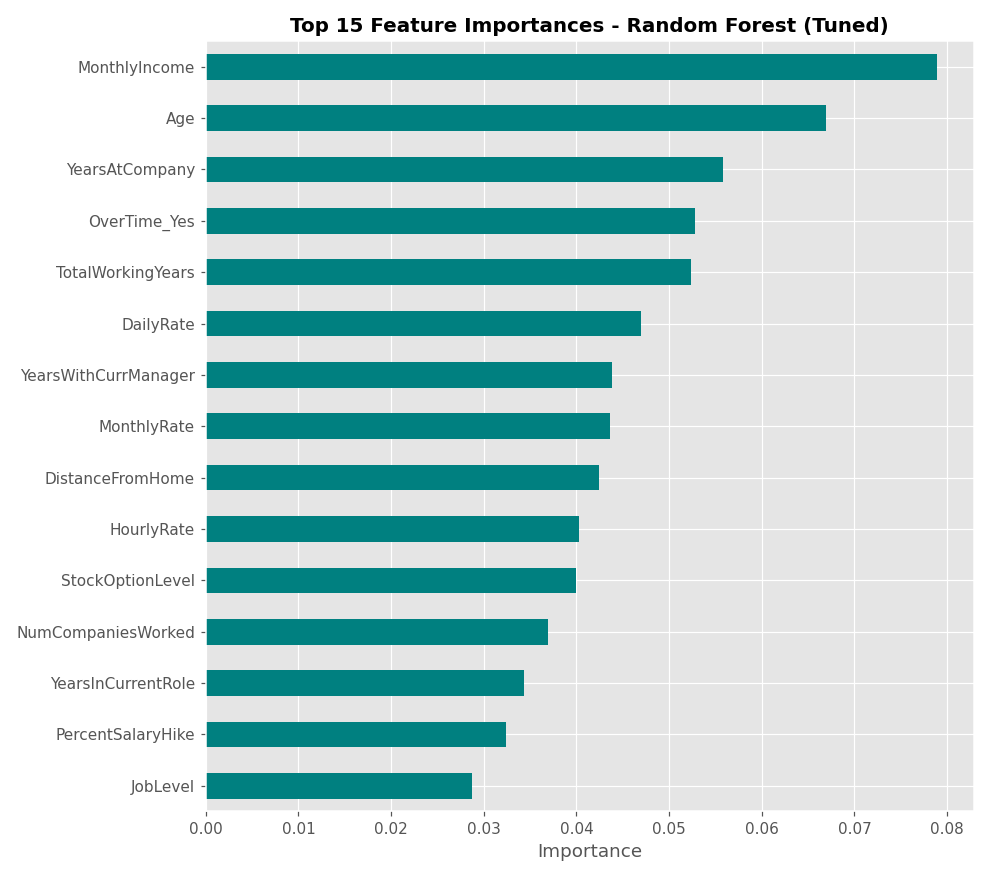

In [1]:
fig, ax = plt.subplots(figsize=(9, 8))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title("Top 15 Feature Importances - Random Forest (Tuned)", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Insight:** the Random Forest's impurity-based feature importances put **MonthlyIncome, Age, YearsAtCompany, OverTime and TotalWorkingYears** at the top — directly mirroring the strongest signals uncovered in the EDA's t-tests and Cramér's V analysis. This cross-validates the earlier statistical findings with an independent, model-based ranking: compensation, experience/tenure, and overtime status are consistently the dominant attrition drivers across both the descriptive and predictive phases of the project.

### 5.8 Coefficient Interpretation — Logistic Regression

In [1]:
coefs = pd.Series(best_lr.coef_[0], index=X_train_scaled.columns).sort_values()
top_bottom = pd.concat([coefs.head(10), coefs.tail(10)])
top_bottom.round(4)

EducationField_Other                -1.8248
JobRole_Research Director           -1.6786
EducationField_Life Sciences        -1.1321
EducationField_Medical              -1.0631
EducationField_Marketing            -0.8971
TotalWorkingYears                   -0.6994
EducationField_Technical Degree     -0.5031
YearsWithCurrManager                -0.4767
JobInvolvement                      -0.4070
EnvironmentSatisfaction             -0.4052
JobRole_Research Scientist           0.8067
Department_Research & Development    0.8892
MaritalStatus_Single                 0.9853
BusinessTravel_Travel_Rarely         1.1511
Department_Sales                     1.2903
OverTime_Yes                         1.7180
BusinessTravel_Travel_Frequently     1.8678
JobRole_Laboratory Technician        2.1258
JobRole_Human Resources              2.1507
JobRole_Sales Representative         2.3081
dtype: float64

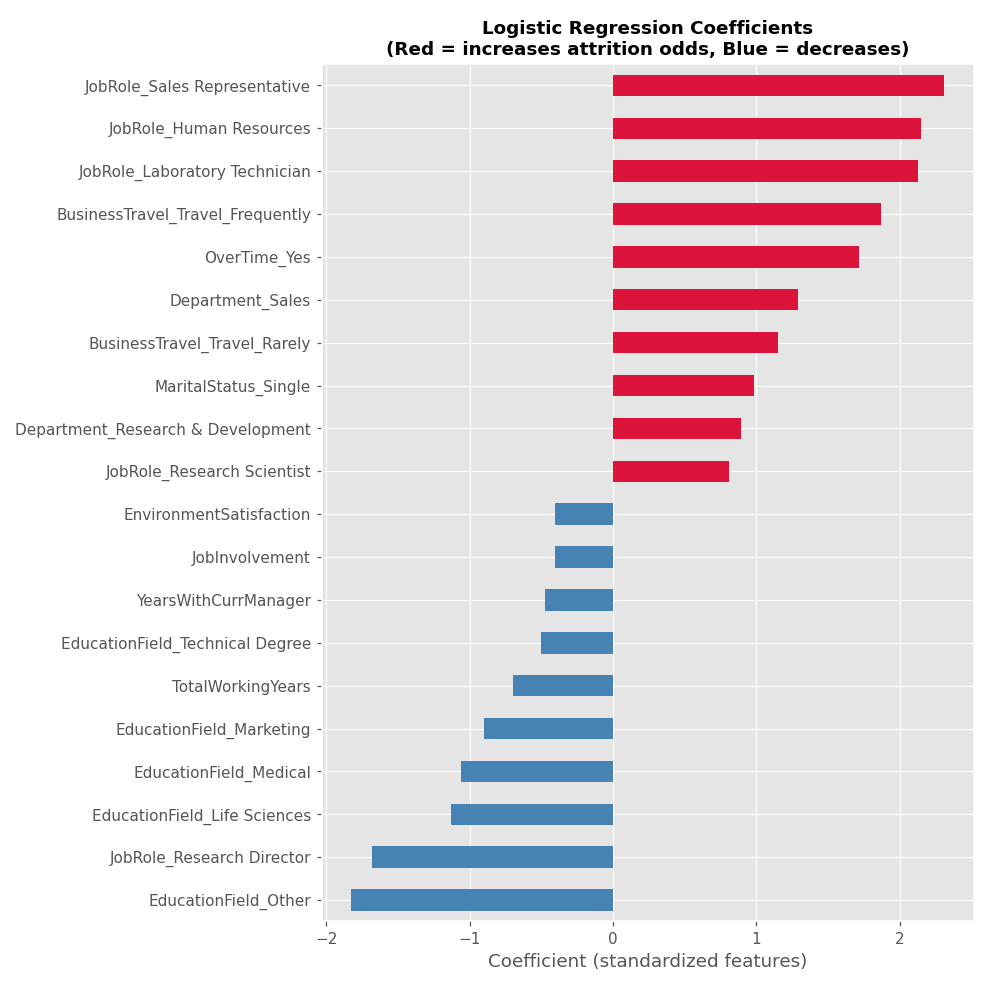

In [1]:
fig, ax = plt.subplots(figsize=(9, 9))
colors = ['crimson' if v > 0 else 'steelblue' for v in top_bottom.values]
top_bottom.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Logistic Regression Coefficients\n(Red = increases attrition odds, Blue = decreases)", fontsize=12, fontweight='bold')
ax.set_xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

**Insight:** the coefficients give a directional, employee-level explanation that the tree models can't easily provide. Working overtime, frequent business travel, being a Sales Representative, HR, or Lab Technician, being in Sales/R&D departments, and being single are all associated with *higher* odds of leaving. Conversely, more total working years, longer tenure with the current manager, higher job involvement and environment satisfaction, and certain job roles/education fields (Research Director, Life Sciences, Medical) are associated with *lower* odds of leaving. This is consistent with — and adds nuance to — the EDA's finding that OverTime and JobRole were the strongest categorical associations with attrition.

### 5.9 Permutation Importance (Model-Agnostic Validation)
Permutation importance measures the actual drop in ROC-AUC when a feature's values are randomly shuffled — a more reliable, less biased alternative to impurity-based importance, and directly computed against the held-out test set.

In [1]:
perm = permutation_importance(best_rf, X_test_scaled, y_test, n_repeats=20,
                                random_state=RANDOM_STATE, scoring='roc_auc')
perm_series = pd.Series(perm.importances_mean, index=X_test_scaled.columns).sort_values(ascending=False)
perm_series.head(15).round(4)

OverTime_Yes                        0.0780
StockOptionLevel                    0.0227
JobSatisfaction                     0.0177
MonthlyIncome                       0.0128
EnvironmentSatisfaction             0.0090
Age                                 0.0088
JobLevel                            0.0077
YearsSinceLastPromotion             0.0070
JobInvolvement                      0.0065
YearsInCurrentRole                  0.0062
DistanceFromHome                    0.0061
MaritalStatus_Single                0.0052
RelationshipSatisfaction            0.0046
TrainingTimesLastYear               0.0037
BusinessTravel_Travel_Frequently    0.0030
dtype: float64

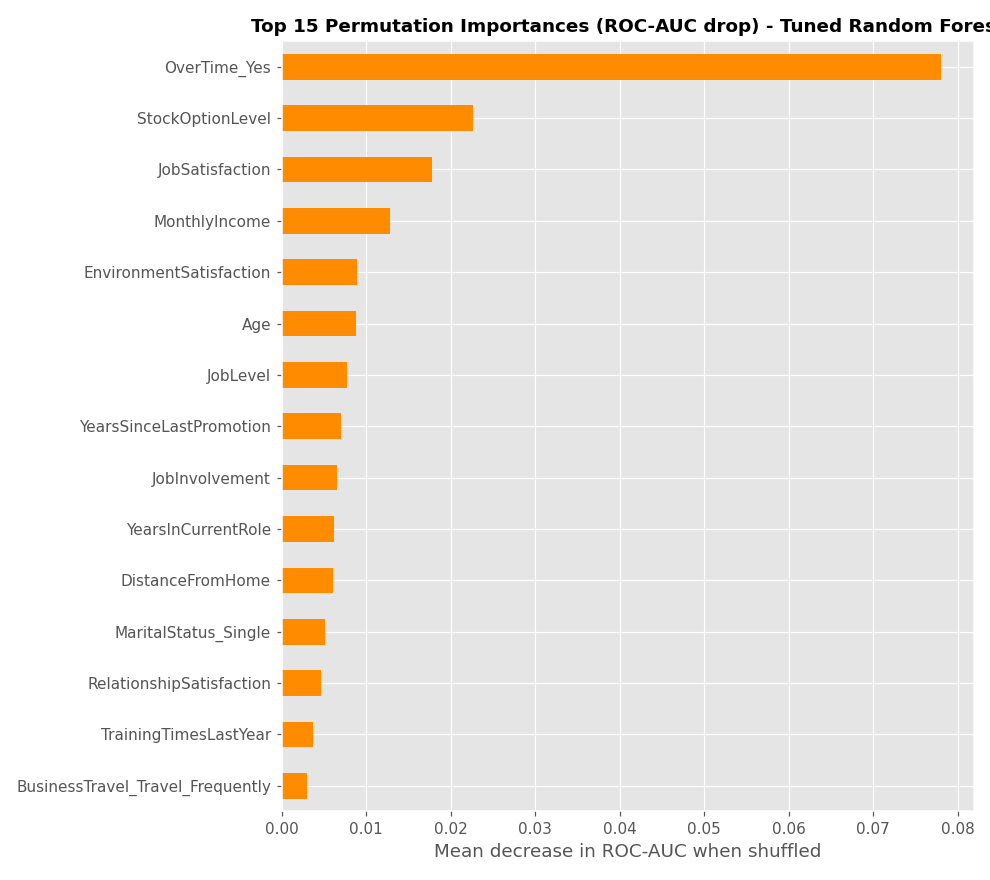

In [1]:
fig, ax = plt.subplots(figsize=(9, 8))
perm_series.head(15).sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title("Top 15 Permutation Importances (ROC-AUC drop) - Tuned Random Forest", fontsize=12, fontweight='bold')
ax.set_xlabel("Mean decrease in ROC-AUC when shuffled")
plt.tight_layout()
plt.show()

**Insight:** permutation importance tells a sharper story than the impurity-based ranking — **OverTime dominates by a wide margin** (0.078 ROC-AUC drop, more than 3x the next feature), followed by StockOptionLevel, JobSatisfaction and MonthlyIncome. This realigns the model interpretation closer to the EDA's Cramér's V ranking, where OverTime (V=0.244) was the single strongest categorical predictor. The takeaway: when a feature is actually removed from the model's ability to use it, overtime status is by far the most damaging to lose — reinforcing it as the top lever for intervention, ahead of compensation.

### 5.10 Classification Threshold Analysis

The default 0.5 probability threshold isn't necessarily optimal for an imbalanced problem where missing a leaver (false negative) is often costlier to the business than an unnecessary retention conversation (false positive). This scans thresholds on the tuned Random Forest to see how precision, recall and F1 trade off.

In [1]:
thresholds = np.arange(0.1, 0.9, 0.05)
thresh_results = []
for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    thresh_results.append({
        "threshold": round(t,2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })
thresh_df = pd.DataFrame(thresh_results)
thresh_df.round(3)

    threshold  precision  recall     f1
0        0.10      0.172   0.979  0.293
1        0.15      0.216   0.936  0.351
2        0.20      0.265   0.872  0.406
3        0.25      0.327   0.787  0.462
4        0.30      0.388   0.660  0.488
5        0.35      0.403   0.532  0.459
6        0.40      0.447   0.447  0.447
7        0.45      0.455   0.319  0.375
8        0.50      0.455   0.213  0.290
9        0.55      0.286   0.085  0.131
10       0.60      0.333   0.085  0.136
11       0.65      0.333   0.064  0.107
12       0.70      0.600   0.064  0.115
13       0.75      0.750   0.064  0.118
14       0.80      0.667   0.043  0.080
15       0.85      1.000   0.043  0.082

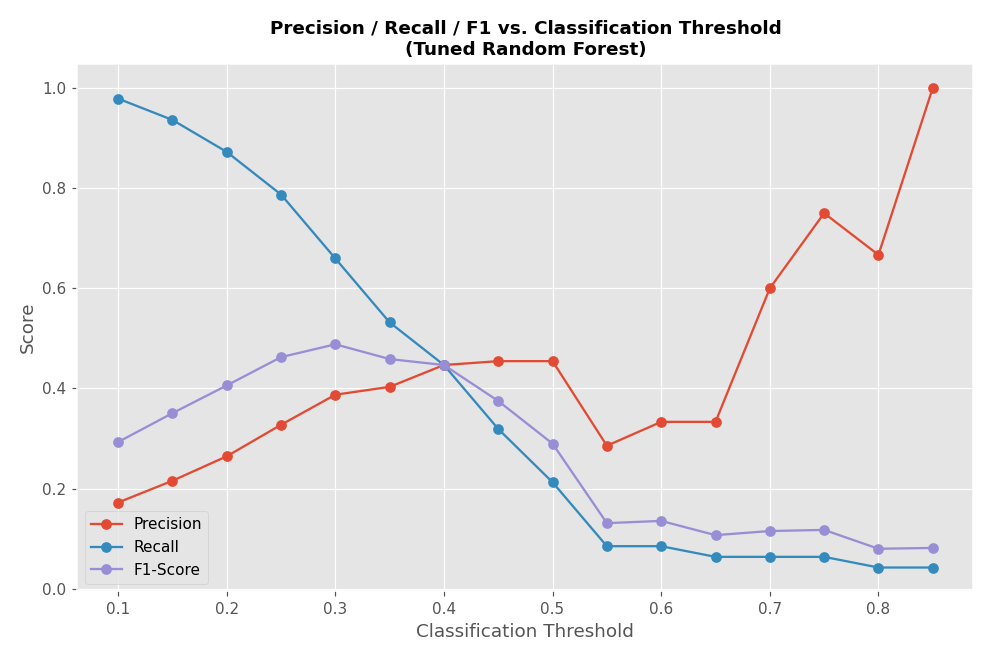

In [1]:
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(thresh_df['threshold'], thresh_df['precision'], marker='o', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'], marker='o', label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'], marker='o', label='F1-Score')
ax.set_xlabel("Classification Threshold"); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Classification Threshold\n(Tuned Random Forest)", fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** lowering the Random Forest's decision threshold from 0.50 to 0.30 lifts recall from 21.3% to 66.0% — matching the SVM's recall — while F1 improves from 0.290 to 0.488, its best value across the sweep. This demonstrates that a model's default threshold is a business choice, not a technical constant: for an attrition early-warning tool, deliberately lowering the threshold to catch more true leavers (accepting more false alarms) is usually the right trade-off, since a missed at-risk employee is typically far costlier to the business than one unnecessary retention conversation.

## Key Model Development & Evaluation Insights

#### 1. Accuracy is a misleading metric on this dataset
With attrition at only 16.12%, accuracy rewards models that ignore the minority class. Random Forest and KNN achieved the highest accuracy (84%+) while catching under 10% of actual leavers — they are effectively "predict everyone stays" models in disguise. Recall, F1-score, and ROC-AUC are the metrics that matter for this use case.

#### 2. SVM and Logistic Regression are the strongest predictive models
Both linear/margin-based models substantially outperform the tree ensembles on ROC-AUC and recall, both in the single test split and under 5-fold cross-validation. SVM (ROC-AUC 0.817, recall 66.0%) is the top performer overall; Logistic Regression (ROC-AUC 0.804, recall 66.0%) is a very close second and offers full interpretability via its coefficients — a strong combination for an HR decision-support tool.

#### 3. Hyperparameter tuning has limited power against class imbalance
Grid search improved Random Forest's recall only from 8.5% to 21.3% — still far short of SVM/Logistic Regression. Tuning parameters cannot fully correct a model whose structure is biased toward the majority class; that requires resampling techniques (e.g. SMOTE/undersampling) or, more simply, threshold adjustment (see #5).

#### 4. Feature importance confirms the EDA — with one refinement
Impurity-based Random Forest importance ranks MonthlyIncome, Age, YearsAtCompany and OverTime highest, echoing the EDA's t-test and Cramér's V results. Permutation importance — a more rigorous, less biased method — sharpens this further: **OverTime is by far the single most damaging feature to lose**, more than 3x the impact of the next-ranked feature (StockOptionLevel), which aligns exactly with OverTime's #1 ranking (V=0.244) in the EDA's Cramér's V analysis.

#### 5. Threshold tuning is a low-cost, high-impact lever
Lowering the classification threshold from 0.50 to 0.30 on the Random Forest roughly triples its recall (21.3% → 66.0%) at a moderate precision cost, without retraining anything. For an attrition early-warning system, this kind of threshold choice — driven by the relative cost of a missed leaver versus a false alarm — is often more impactful than model selection itself.

#### 6. Convergent evidence across EDA and modelling
Both phases now independently point to the same drivers: overtime, compensation, tenure/experience, job role, and satisfaction-related factors. This convergence across two different analytical approaches (statistical association in Phase 2, predictive modelling in Phase 3–4) strengthens confidence that these are genuinely the variables HR should prioritize, even though causation still cannot be claimed from either analysis alone.

## Business Recommendations From Modelling

1. **Deploy SVM or Logistic Regression, not the tree ensembles, for production scoring.** Their materially higher recall means far fewer at-risk employees slip through undetected; Logistic Regression is the pragmatic choice if HR stakeholders need to see *why* an employee was flagged.
2. **Set the decision threshold deliberately, not by default.** A threshold around 0.30 (rather than 0.50) roughly triples recall at an acceptable precision cost — appropriate when the cost of losing an employee outweighs the cost of an unnecessary retention conversation.
3. **Prioritize overtime management as the top intervention lever.** It is the single most damaging feature to lose by permutation importance and the strongest categorical association in the EDA — auditing overtime load by department/role is the highest-leverage next step.
4. **Use the model as a triage tool, not a verdict.** With precision in the 40–45% range, roughly half of flagged employees will not actually leave — the model should prompt a conversation or review, not an automatic action.
5. **Revisit modelling with resampling techniques (SMOTE) if better recall/precision balance is needed**, since hyperparameter tuning alone could not resolve the tree models' bias toward the majority class.

## Conclusion

Six classification models were trained and evaluated on the IBM HR Analytics attrition dataset, addressing the ~84/16 class imbalance through class-weighting, and two top candidates were further tuned via grid search. The Support Vector Machine emerged as the best overall model (ROC-AUC 0.817, recall 66.0%, F1 0.508), closely followed by Logistic Regression, while tree-based ensembles under-performed on recall despite higher raw accuracy — a reminder that accuracy is the wrong metric for imbalanced classification problems.

Feature importance, coefficient, and permutation-importance analyses converged on the same drivers identified in the Phase 3 EDA: overtime, compensation, tenure/experience, job role and satisfaction — with permutation importance singling out OverTime as the single most influential feature. Threshold analysis further showed that recall can be substantially improved through business-driven threshold selection rather than model retraining alone.

Together, Phases 3–5 provide converging statistical and predictive evidence that HR retention efforts should prioritize overtime management, compensation review, and early-career/early-tenure support, while using the trained model as a triage aid to focus retention conversations on the employees most likely to be flagged as at-risk.